In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Fix 1: robust TF/Keras import to avoid protobuf incompatibilities in Kaggle images.
# Prefer tf_keras if it imports cleanly; otherwise fall back to tensorflow.keras.
try:
    import tf_keras as keras
    from tf_keras.models import Sequential
    from tf_keras.layers import Dense, Dropout, Conv2D, MaxPool2D, Flatten
    from tf_keras.callbacks import EarlyStopping, ReduceLROnPlateau
    from tf_keras.optimizers import RMSprop
except Exception as e:
    import tensorflow as tf

    keras = tf.keras
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPool2D, Flatten
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    from tensorflow.keras.optimizers import RMSprop

np.random.seed(42)


def find_dataset_root():
    candidates = [
        "/kaggle/input/aerial-cactus-identification",
        "/kaggle/input/aerial-cactus-identification/aerial-cactus-identification",
        "../input/aerial-cactus-identification",
        "../input/aerial-cactus-identification/aerial-cactus-identification",
        "/kaggle/data/aerial-cactus-identification",
        "/kaggle/data/aerial-cactus-identification/aerial-cactus-identification",
    ]
    for c in candidates:
        if os.path.exists(c):
            # ensure it actually contains train.csv
            if os.path.exists(os.path.join(c, "train.csv")):
                return c
    base = "/kaggle/input"
    if os.path.exists(base):
        for name in os.listdir(base):
            p = os.path.join(base, name)
            if os.path.isdir(p) and (
                "cactus" in name.lower() or "aerial" in name.lower()
            ):
                if os.path.exists(os.path.join(p, "train.csv")):
                    return p
                nested = os.path.join(p, "aerial-cactus-identification")
                if os.path.exists(os.path.join(nested, "train.csv")):
                    return nested
    raise FileNotFoundError(
        "Could not locate aerial-cactus-identification dataset root in the Kaggle environment."
    )


DATA_ROOT = find_dataset_root()
TRAIN_CSV = os.path.join(DATA_ROOT, "train.csv")
SAMPLE_SUB = os.path.join(DATA_ROOT, "sample_submission.csv")

# ---- Fix 2: correct image directories (dataset structure is .../train/*.jpg and .../test/*.jpg)
TRAIN_DIR = os.path.join(DATA_ROOT, "train")
TEST_DIR = os.path.join(DATA_ROOT, "test")

train_df = pd.read_csv(TRAIN_CSV)
print("DATA_ROOT:", DATA_ROOT)
print(
    "TRAIN_DIR exists:",
    os.path.exists(TRAIN_DIR),
    "num files:",
    len([f for f in os.listdir(TRAIN_DIR) if f.lower().endswith(".jpg")]),
)
print(
    "TEST_DIR exists:",
    os.path.exists(TEST_DIR),
    "num files:",
    len([f for f in os.listdir(TEST_DIR) if f.lower().endswith(".jpg")]),
)
print(train_df.head())
print("train_df shape:", train_df.shape)



2026-01-10 21:22:45.415540: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768080165.428997      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768080165.433117      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-10 21:22:45.449399: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

DATA_ROOT: /kaggle/input/aerial-cactus-identification
TRAIN_DIR exists: True num files: 14175
TEST_DIR exists: True num files: 3325
                                     id  has_cactus
0  2de8f189f1dce439766637e75df0ee27.jpg           1
1  36704d250f236238e7f996812c48235d.jpg           1
2  eacde22fdc8c175972a5768e3daa8bc9.jpg           1
3  5d442f834da5e57d22b24802c32a8ca8.jpg           1
4  152491e0daf75c0e669400300ff7e645.jpg           1
train_df shape: (14175, 2)


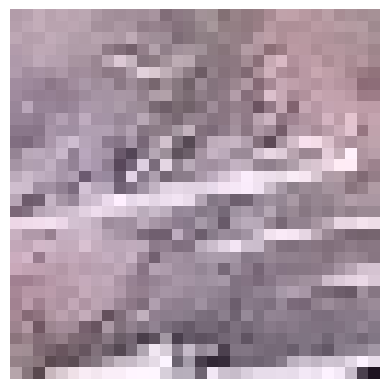

Image shape: (32, 32, 3)


In [2]:
test_file = train_df.iloc[100, 0]
im = plt.imread(os.path.join(TRAIN_DIR, test_file))
plt.imshow(im)
plt.axis("off")
plt.show()
print("Image shape:", im.shape)



In [3]:
train_df.describe(include="all")



/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,id,has_cactus
count,14175,14175.000000
unique,14175,NaN
top,2de8f189f1dce439766637e75df0ee27.jpg,NaN
freq,1,NaN
mean,NaN,0.749771
std,NaN,0.433160
min,NaN,0.000000
25%,NaN,0.000000
50%,NaN,1.000000
75%,NaN,1.000000


In [4]:
y_train = train_df["has_cactus"].values.astype("float32")
im_list = train_df["id"].values

X_train = np.zeros((len(im_list), 32, 32, 3), dtype="float32")

for idx, fp in enumerate(im_list):
    image = plt.imread(os.path.join(TRAIN_DIR, fp))
    X_train[idx] = image.astype("float32")

print(
    "X_train:", X_train.shape, X_train.dtype, "y_train:", y_train.shape, y_train.dtype
)



X_train: (14175, 32, 32, 3) float32 y_train: (14175,) float32


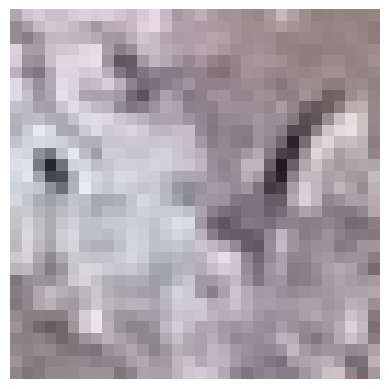

y_train[10] = 0.0


In [5]:
plt.imshow(X_train[10] / 255.0)
plt.axis("off")
plt.show()
print("y_train[10] =", y_train[10])



In [6]:
X_train_scaled = X_train / 255.0



In [7]:
cactus = Sequential()

cactus.add(
    Conv2D(
        filters=32,
        kernel_size=(5, 5),
        activation="relu",
        padding="same",
        input_shape=(32, 32, 3),
    )
)
cactus.add(Conv2D(filters=32, kernel_size=(5, 5), activation="relu", padding="same"))
cactus.add(MaxPool2D(pool_size=(2, 2)))
cactus.add(Dropout(0.2))

cactus.add(Conv2D(filters=64, kernel_size=(3, 3), activation="relu", padding="same"))
cactus.add(Conv2D(filters=64, kernel_size=(3, 3), activation="relu", padding="same"))
cactus.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))
cactus.add(Dropout(0.2))

cactus.add(Flatten())
cactus.add(Dense(256, activation="relu"))
cactus.add(Dropout(0.50))

cactus.add(Dense(1, activation="sigmoid"))

opt = RMSprop(learning_rate=0.001, rho=0.9, epsilon=1e-08)

lrreduce = ReduceLROnPlateau(
    monitor="val_accuracy", patience=3, verbose=1, factor=0.5, min_lr=1e-5
)

cactus.compile(optimizer=opt, loss="binary_crossentropy", metrics=["accuracy"])



2026-01-10 21:22:55.047702: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1768080175.048136      11 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:c6:00.0, compute capability: 8.6


In [8]:
cactus.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 32)        2432      
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 32)        25632     
                                                                 
 max_pooling2d (MaxPooling2  (None, 16, 16, 32)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 16, 16, 32)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 16, 16, 64)        36928     
                                                        

In [9]:
estop = EarlyStopping(patience=3, restore_best_weights=True)



In [10]:
history = cactus.fit(
    X_train_scaled,
    y_train,
    validation_split=0.15,
    verbose=2,
    epochs=30,
    batch_size=100,
    callbacks=[lrreduce],
)



Epoch 1/30


E0000 00:00:1768080175.906623      11 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1768080175.976514      67 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1768080177.011104      68 service.cc:148] XLA service 0x7fb2084ac1d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768080177.011143      68 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2026-01-10 21:22:57.015898: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1768080177.058275      68 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


121/121 - 3s - loss: 0.5582 - accuracy: 0.7419 - val_loss: 0.4351 - val_accuracy: 0.7668 - lr: 0.0010 - 3s/epoch - 27ms/step
Epoch 2/30
121/121 - 0s - loss: 0.3714 - accuracy: 0.8338 - val_loss: 0.3508 - val_accuracy: 0.8524 - lr: 0.0010 - 463ms/epoch - 4ms/step
Epoch 3/30
121/121 - 0s - loss: 0.2400 - accuracy: 0.9071 - val_loss: 0.8446 - val_accuracy: 0.6361 - lr: 0.0010 - 465ms/epoch - 4ms/step
Epoch 4/30
121/121 - 0s - loss: 0.1726 - accuracy: 0.9340 - val_loss: 0.1150 - val_accuracy: 0.9567 - lr: 0.0010 - 461ms/epoch - 4ms/step
Epoch 5/30
121/121 - 0s - loss: 0.1251 - accuracy: 0.9518 - val_loss: 0.1261 - val_accuracy: 0.9506 - lr: 0.0010 - 458ms/epoch - 4ms/step
Epoch 6/30
121/121 - 0s - loss: 0.1120 - accuracy: 0.9612 - val_loss: 0.0555 - val_accuracy: 0.9798 - lr: 0.0010 - 460ms/epoch - 4ms/step
Epoch 7/30
121/121 - 0s - loss: 0.0858 - accuracy: 0.9690 - val_loss: 0.1344 - val_accuracy: 0.9408 - lr: 0.0010 - 461ms/epoch - 4ms/step
Epoch 8/30
121/121 - 0s - loss: 0.0637 - accura

In [11]:
fileid = []


def read_in_test(dirstr, expected_ids=None):
    """
    Fix:
    - Always return X in exactly expected_ids order (from sample_submission).
    - Ensure fileid and X have identical lengths by appending every filename (no continues that desync).
    """
    global fileid
    fileid = []

    if expected_ids is None:
        filenames = sorted(
            [f for f in os.listdir(dirstr) if f.lower().endswith(".jpg")]
        )
    else:
        filenames = list(expected_ids)

    out_array = np.zeros((len(filenames), 32, 32, 3), dtype="float32")

    for idx, filename in enumerate(filenames):
        fp = os.path.join(dirstr, filename)
        if not os.path.isfile(fp):
            raise FileNotFoundError(f"Missing test image: {fp}")
        fileid.append(filename)
        out_array[idx] = plt.imread(fp).astype("float32")

    return out_array / 255.0




In [12]:
sample_sub = pd.read_csv(SAMPLE_SUB)
expected_test_ids = sample_sub["id"].values

X_test = read_in_test(TEST_DIR, expected_ids=expected_test_ids)
print(
    "X_test:", X_test.shape, "fileid:", len(fileid), "expected:", len(expected_test_ids)
)



X_test: (3325, 32, 32, 3) fileid: 3325 expected: 3325


In [13]:
out = cactus.predict(X_test, batch_size=256, verbose=0)



In [14]:
print("Pred shape:", out.shape, "ravel shape:", out.ravel().shape)



Pred shape: (3325, 1) ravel shape: (3325,)


In [15]:
# Fix: ensure lengths match and ordering matches sample_submission exactly
if len(fileid) != out.shape[0]:
    raise RuntimeError(
        f"Length mismatch: len(fileid)={len(fileid)} vs preds={out.shape[0]}"
    )

sub = pd.DataFrame({"id": fileid, "has_cactus": out.ravel().astype("float64")})

# Force exact order/row count as sample submission (safe and score-neutral)
sub = sample_sub[["id"]].merge(sub, on="id", how="left")
if sub["has_cactus"].isna().any():
    sub["has_cactus"] = sub["has_cactus"].fillna(float(np.nanmean(out)))

print(sub.shape)
print(sub.head())



(3325, 2)
                                     id  has_cactus
0  09034a34de0e2015a8a28dfe18f423f6.jpg         1.0
1  134f04305c795d6d202502c2ce3578f3.jpg         1.0
2  41fad8d145e6c41868ce3617e30a2545.jpg         1.0
3  35f8a11352c8d41b6231bb33d8d09f7e.jpg         1.0
4  b77dc902b035887cbbc01920ce0e3151.jpg         1.0


In [16]:
sub.to_csv("submission.csv", index=False)
print("Wrote submission.csv with columns:", list(sub.columns))
print("submission.csv preview:\n", sub.head().to_string(index=False))
print("submission.csv rows:", len(sub))

Wrote submission.csv with columns: ['id', 'has_cactus']
submission.csv preview:
                                   id  has_cactus
09034a34de0e2015a8a28dfe18f423f6.jpg         1.0
134f04305c795d6d202502c2ce3578f3.jpg         1.0
41fad8d145e6c41868ce3617e30a2545.jpg         1.0
35f8a11352c8d41b6231bb33d8d09f7e.jpg         1.0
b77dc902b035887cbbc01920ce0e3151.jpg         1.0
submission.csv rows: 3325
